In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = "Nimbus Roman"


import sys, os
sys.path.append(os.path.join(os.getcwd(), ".."))

from ml_force.models import LIF
from ml_force import z_transform
from ml_force import LorenzAttractor, VanDerPol

In [29]:
T = 5000
dt = 1e-1
t = np.arange(0, T, dt)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sup = LorenzAttractor(T=T, dt=dt, tau=0.02).generate(transient_time=1000)
sup = sup.T
sup = z_transform(sup)
print(sup.shape)


(50000, 3)


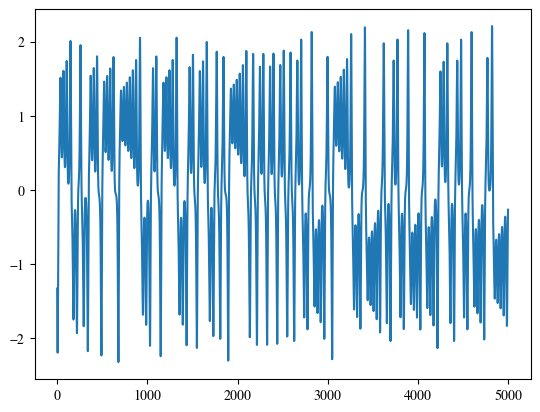

In [30]:
plt.plot(t, sup[:, 0])
plt.show()

## LIF Model

In [4]:
N = 500

lif = LIF(device=device, N=N, T=T, dt=dt, sup=sup, 
          tau_s=20, tau_m=10, I=100,
          G=20, Q=500, l=1e-6)
print(lif.x_hat.shape)
print(device)

torch.Size([3, 1])
cuda


Training epoch 1/5


100%|██████████| 41999/41999 [00:08<00:00, 5002.10it/s]


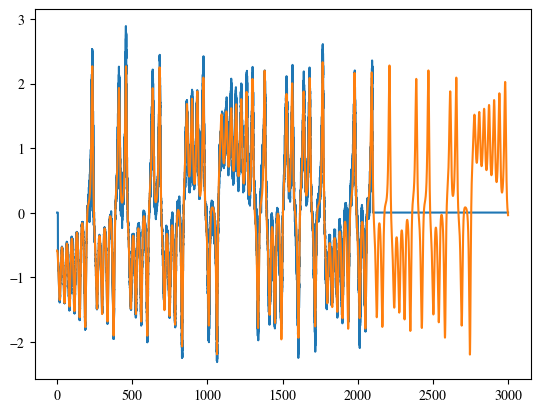

Training epoch 2/5


 54%|█████▍    | 22744/41999 [00:04<00:03, 5201.91it/s]


KeyboardInterrupt: 

In [5]:
rls_start = 100
rls_stop = T * .70
rls_step = 5

n_epochs = 5
# lif.epoch_train(rls_stop=rls_stop, rls_step=rls_step, n_epochs=10)

for i in range(n_epochs):
    print(f"Training epoch {i+1}/{n_epochs}")
    lif.__reinit__()
    lif._train(rls_stop, rls_step)
    
    plt.plot(t, lif.x_hat_rec[:, 0].cpu().numpy())
    plt.plot(t, sup[:, 0])
    plt.show()
    plt.close()


In [ ]:
lif.render(rls_start=0, rls_stop=-1, rls_step=10)

100%|██████████| 60000/60000 [00:10<00:00, 5706.33it/s]


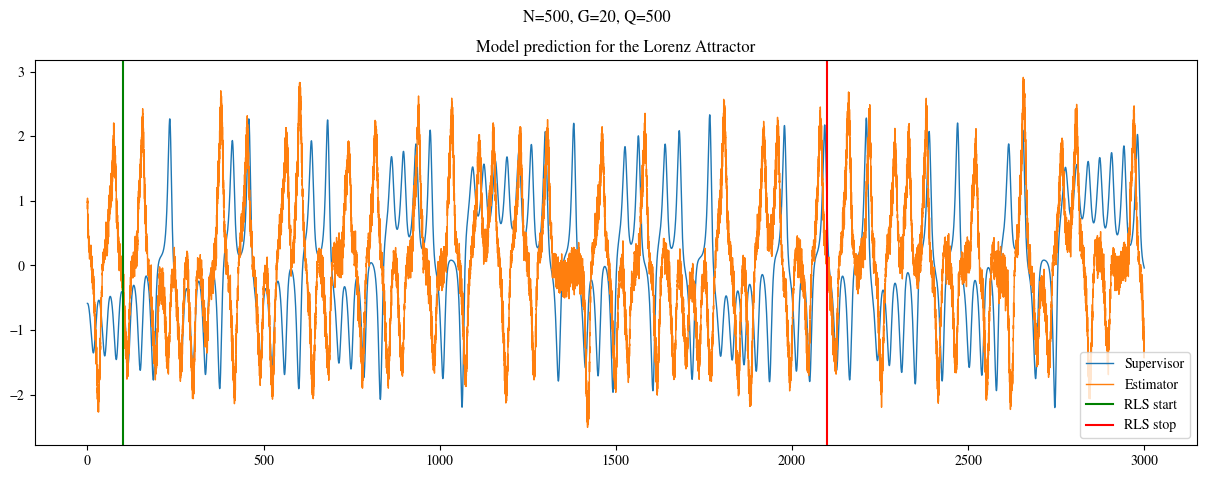

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

test_start = 0
plt.plot(t[test_start:], sup[test_start:, 0], lw=1, label="Supervisor")
plt.plot(t[test_start:], lif.x_hat_rec[test_start:, 0].cpu().numpy(),
         lw=1, label="Estimator")
plt.axvline(x=rls_start, c='green', label="RLS start")
plt.axvline(x=rls_stop, c='red', label="RLS stop")
plt.legend(loc=0)
plt.title("Model prediction for the Lorenz Attractor")
plt.suptitle(f"N={lif.N}, G={lif.G}, Q={lif.Q}")
plt.show()

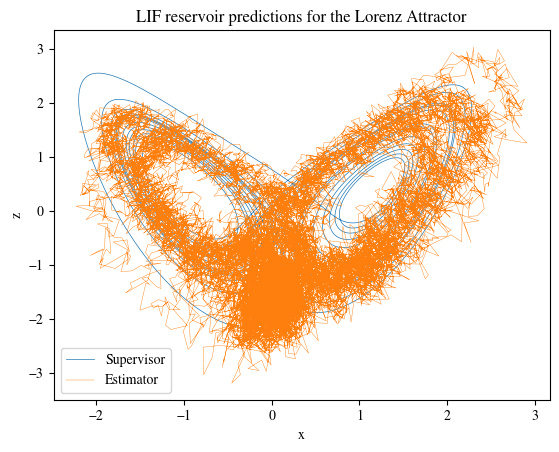

In [ ]:
xhat = lif.x_hat_rec.cpu().numpy()

test_start = round(rls_stop // dt)
plt.plot(sup[test_start:, 0], sup[test_start:, 2], lw=.5, label="Supervisor")
plt.plot(xhat[test_start:, 0], xhat[test_start:, 2], lw=.3, label="Estimator")
plt.legend(loc=0)
plt.xlabel("x")
plt.ylabel("z")
plt.title("LIF reservoir predictions for the Lorenz Attractor")
# plt.savefig("img/lif_lorenz_portrait.jpg", dpi=600, bbox_inches='tight')
plt.show()

## Morris-Lecar Model

In [40]:
from ml_force.models import MorrisLecar

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

NE = 600
NI = 600
N = NI + NE

# input current for I and E neurons
Ie = 85
Ii = 85
current = np.ones((N, 1))
middle = N // 2
current[:middle] *= Ie  # NE bias
current[middle:] *= Ii  # NI bias
# current = np.random.rand(N, 1) * Ie

# RLS params
# rls_start = round(T * .02)
# rls_stop = round(T * .85)
# test_time = 4000    # ms
# rls_stop = T - test_time
rls_start = 100
rls_stop = T * 0.70
rls_step = 5

Q = 200
lamda = 1e-3
gbar = 15

ml = MorrisLecar(supervisor=sup, dt=dt, T=T, N=N, BIAS=current, gbar=gbar, Q=Q, l=lamda, device=device)


Transient Time:


100%|██████████| 1999/1999 [00:01<00:00, 1401.50it/s]


Training time:


100%|██████████| 34999/34999 [00:29<00:00, 1199.02it/s]


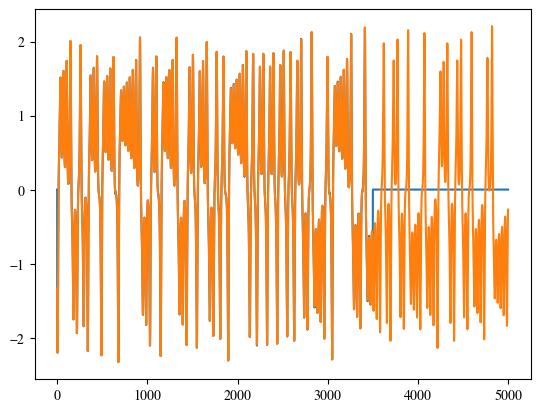

In [41]:
n_epochs = 1

for i in range(n_epochs):
    ml.__reinit__()
    ml._train(rls_stop=rls_stop, rls_step=rls_step, transient_time=200)
    
    plt.plot(t, ml.x_hat_rec[:, 0].cpu().numpy(), label="estimator")
    plt.plot(t, sup[:, 0], label="supervisor")
    plt.show()
    plt.close()


In [42]:
print(ml.dec.max())

tensor(4.2481, device='cuda:0', dtype=torch.float64)


In [43]:
from tqdm import tqdm


rls_stop_ind = int(rls_stop // ml._dt)

for i in tqdm(range(rls_stop_ind, ml._nt)):
    ml.euler_step()
    ml.x_hat_rec[i] = ml.x_hat[:, 0]

100%|██████████| 15001/15001 [00:10<00:00, 1382.32it/s]


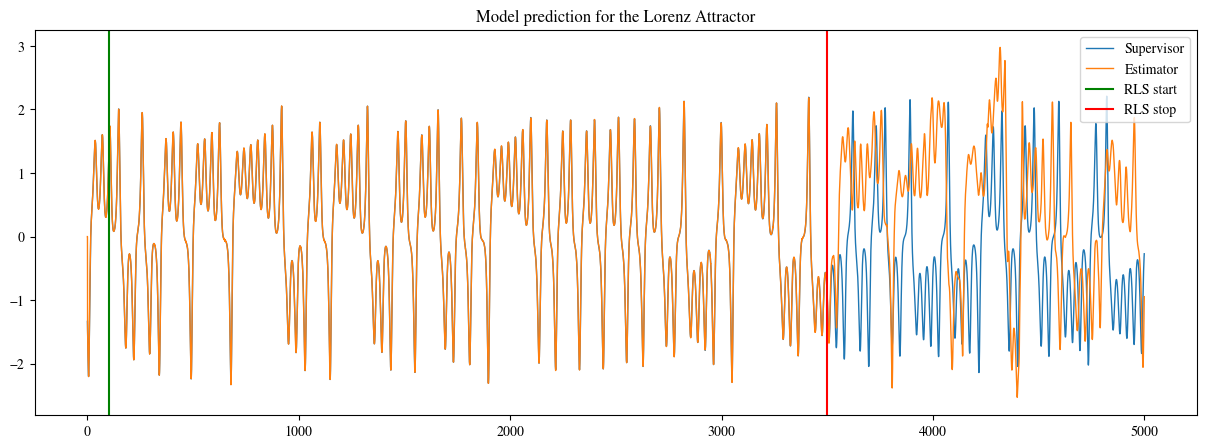

In [44]:
fig, ax = plt.subplots(figsize=(15, 5))

test_start = 0
plt.plot(t[test_start:], sup[test_start:, 0], lw=1, label="Supervisor")
plt.plot(t[test_start:], ml.x_hat_rec[test_start:, 0].cpu().numpy(),
         lw=1, label="Estimator")
plt.axvline(x=rls_start, c='green', label="RLS start")
plt.axvline(x=rls_stop, c='red', label="RLS stop")
plt.legend(loc=0)
plt.title("Model prediction for the Lorenz Attractor")
# plt.title(f"N={ml._N}, G={ml.gbar}")
plt.savefig("img/ml_lorenz_output.pdf", bbox_inches='tight')
plt.show()

In [10]:
_, v_trace, dec_trace = ml.render(rls_start, rls_stop=-1, rls_step=20, 
                                  live_plot=False, plt_interval=100, 
                                  n_neurons=10, save_all=False)


100%|██████████| 60000/60000 [00:20<00:00, 2997.37it/s]


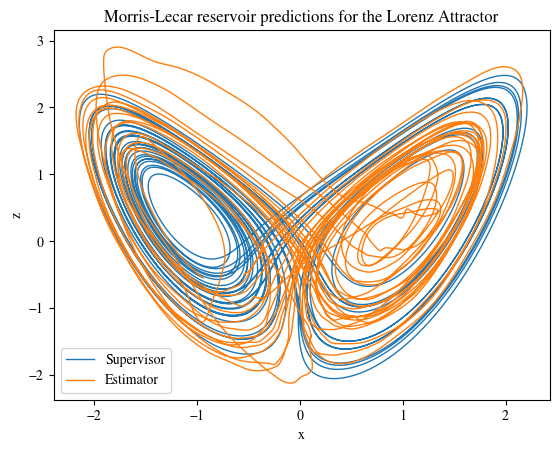

In [36]:
xhat = ml.x_hat_rec.cpu().numpy()
step = 1

test_start = round(rls_stop // dt)
plt.plot(sup[test_start::step, 0], sup[test_start::step, 2], lw=1, label="Supervisor")
plt.plot(xhat[test_start::step, 0], xhat[test_start::step, 2], lw=1, label="Estimator")
plt.legend(loc=0)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Morris-Lecar reservoir predictions for the Lorenz Attractor")
plt.savefig("img/ml_lorenz_portrait.jpg", dpi=600, bbox_inches='tight')
plt.show()

# Return Maps

In [37]:
from scipy.signal import find_peaks

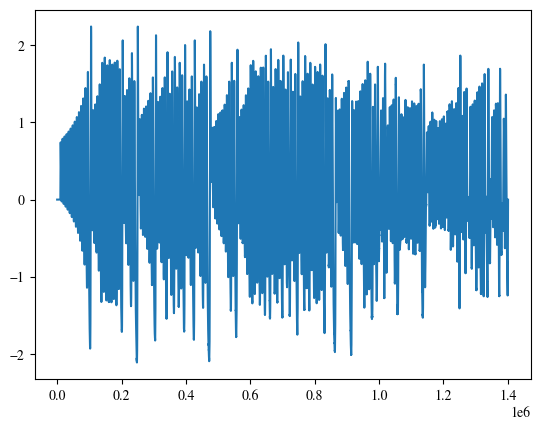

In [7]:
lif_signal = lif.x_hat_rec[:, 2].cpu().numpy()
# lif_signal = lif_signal[lif_signal > 0]

window = 1000
kernel = np.ones((window, ))
kernel /= kernel.sum()
lif_signal = np.convolve(a=lif_signal, v=kernel, mode='full')

plt.plot(np.arange(len(lif_signal)), lif_signal)
plt.show()

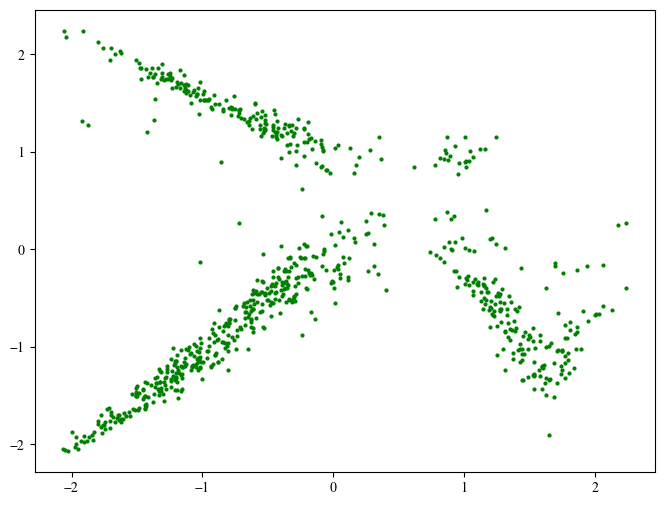

In [10]:
peaks = find_peaks(lif_signal, distance=500)[0]
# print(peaks)
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(lif_signal[peaks[:-1]], lif_signal[peaks[1:]], 'go', ms=2)
# plt.xlim(0, 3)
# plt.ylim(0, 3)
# plt.title("Return Map using LIF")
fs = 26
# plt.xlabel(r"previous $x_{max}$", fontsize=fs)
# plt.ylabel(r"$x_{max}$", fontsize=fs)
plt.savefig("img/lif_lorenz_return_map.jpg", dpi=600, bbox_inches='tight')
plt.show()
plt.close()

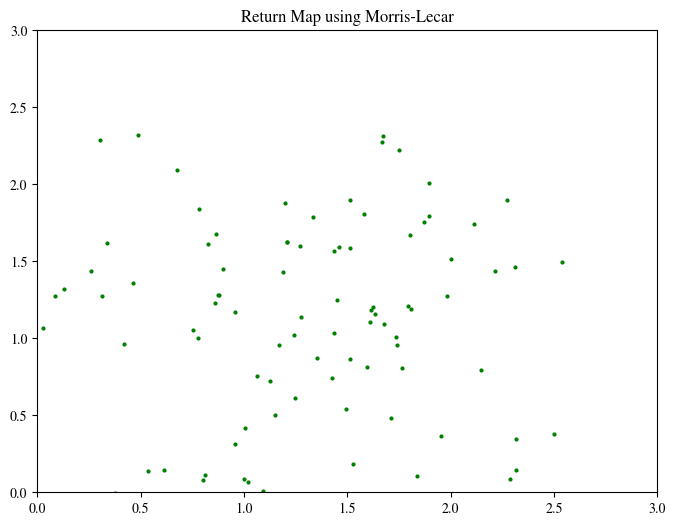

In [40]:
ml_signal = ml.x_hat_rec[:, 2].cpu().numpy()
# ml_signal = ml_signal[ml_signal > 0]
peaks = find_peaks(ml_signal, distance=50)[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ml_signal[peaks[:-1]], ml_signal[peaks[1:]], 'go', ms=2)
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_title("Return Map using Morris-Lecar")
plt.savefig("img/ml_lorenz_return_map.jpg", dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)